# Nighttime Thermal Typology and Policy-Priority Mapping

This notebook converts the three-part nighttime thermal analysis into a spatial policy product at the **INSEE 200 m grid-cell level**.

It creates:

1. a thermal typology based on mean late-night and early-morning land-surface temperature;
2. a cooling-strength qualifier;
3. a transparent social-vulnerability index;
4. combined policy-priority classes;
5. a GeoPackage that can be styled and mapped directly in QGIS.

## Conceptual framework

The classification distinguishes:

- **Persistent nighttime heat**: hot late at night and still hot in the early morning;
- **Hot start with overnight relief**: hot late at night but comparatively cooler in the early morning;
- **Unexpected early-morning warmth**: comparatively cooler late at night but hot in the early morning;
- **Cooler throughout the night**: comparatively cooler in both windows.

Cooling magnitude is retained as a secondary descriptor because a grid cell may cool strongly and still remain hot.

## Important interpretation

This is a **relative metropolitan typology**, not a medical heat-health threshold. By default, “hot” and “high vulnerability” are defined using metropolitan medians. Alternative quartile-based classifications are also created for sensitivity analysis.


In [1]:
# ============================================================
# 1. IMPORT PACKAGES
# ============================================================

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)


In [2]:
# ============================================================
# 2. USER SETTINGS
# ============================================================
# Edit these paths before running the notebook.

# Input: harmonized three-part panel created by Notebook 02
INPUT_GPKG = Path(
    r"C:\Users\kbonsu\Desktop\AICC Conference"
    r"\ECOSTRESS_data_processing\output"
    r"\july_paris_three_part_thermal_harmonized.gpkg"
)

# Output folder
OUTPUT_DIR = Path(
    r"C:\Users\kbonsu\Desktop\AICC Conference"
    r"\ECOSTRESS_data_processing\output\policy_priority"
)

# Output GeoPackage
OUTPUT_GPKG = OUTPUT_DIR / "nighttime_thermal_policy_priority_200m.gpkg"

# Main threshold method:
#   "median"       -> divides the metropolitan distribution into two equal groups
#   "upper_quartile" -> identifies only the hottest / most vulnerable 25%
MAIN_THRESHOLD_METHOD = "median"

# Whether to include mean income in the vulnerability index.
# Income is sign-reversed so that lower income increases vulnerability.
INCLUDE_LOW_INCOME = True

# Create output directory if it does not yet exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_GPKG)
print("Output:", OUTPUT_GPKG)
print("Main threshold method:", MAIN_THRESHOLD_METHOD)


Input: C:\Users\kbonsu\Desktop\AICC Conference\ECOSTRESS_data_processing\output\july_paris_three_part_thermal_harmonized.gpkg
Output: C:\Users\kbonsu\Desktop\AICC Conference\ECOSTRESS_data_processing\output\policy_priority\nighttime_thermal_policy_priority_200m.gpkg
Main threshold method: median


In [3]:
# ============================================================
# 3. LOAD AND VALIDATE THE HARMONIZED DATA
# ============================================================

gdf = gpd.read_file(INPUT_GPKG)

required_columns = {
    "grid_id",
    "year",
    "late_night",
    "early_morning",
    "cooling_magnitude_raw",
    "NCD_raw",
    "poverty_rate",
    "social_share",
    "elderly_share",
    "child_broad_share",
    "single_parent_share",
    "single_person_share",
    "mean_income",
    "geometry",
}

missing_columns = required_columns.difference(gdf.columns)

if missing_columns:
    raise ValueError(
        "The harmonized dataset is missing required columns: "
        f"{sorted(missing_columns)}"
    )

# Validate the three thermal identities before classification.
assert np.allclose(
    gdf["NCD_raw"],
    gdf["early_morning"] - gdf["late_night"],
    equal_nan=True,
), "NCD_raw is inconsistent with the two temperature windows."

assert np.allclose(
    gdf["cooling_magnitude_raw"],
    gdf["late_night"] - gdf["early_morning"],
    equal_nan=True,
), "cooling_magnitude_raw is inconsistent with the two temperature windows."

assert np.allclose(
    gdf["NCD_raw"],
    -gdf["cooling_magnitude_raw"],
    equal_nan=True,
), "NCD_raw and cooling_magnitude_raw are not exact sign reversals."

print(f"Rows: {len(gdf):,}")
print(f"Unique grid cells: {gdf['grid_id'].nunique():,}")
print("Years:", sorted(gdf["year"].dropna().unique()))
print("CRS:", gdf.crs)


Rows: 57,813
Unique grid cells: 13,964
Years: [np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2025)]
CRS: EPSG:2154


## Why aggregate to one record per grid cell?

The harmonized dataset contains repeated observations across years. Policy mapping requires one spatial record per 200 m cell. The notebook therefore calculates temporal means for the thermal and vulnerability variables, while retaining one geometry per grid cell.


In [4]:
# ============================================================
# 4. AGGREGATE TO ONE RECORD PER 200 M GRID CELL
# ============================================================

aggregation_variables = {
    "mean_late_night": ("late_night", "mean"),
    "mean_early_morning": ("early_morning", "mean"),
    "mean_cooling_magnitude": ("cooling_magnitude_raw", "mean"),
    "mean_NCD": ("NCD_raw", "mean"),
    "poverty_rate": ("poverty_rate", "mean"),
    "social_share": ("social_share", "mean"),
    "elderly_share": ("elderly_share", "mean"),
    "child_share": ("child_broad_share", "mean"),
    "single_parent_share": ("single_parent_share", "mean"),
    "single_person_share": ("single_person_share", "mean"),
    "mean_income": ("mean_income", "mean"),
    "n_years": ("year", "nunique"),
    "n_observations": ("year", "size"),
}

grid_summary = (
    gdf.drop(columns="geometry")
    .groupby("grid_id", as_index=False)
    .agg(**aggregation_variables)
)

geometry_lookup = (
    gdf[["grid_id", "geometry"]]
    .drop_duplicates(subset="grid_id")
    .copy()
)

geometry_lookup["grid_id"] = geometry_lookup["grid_id"].astype(str)
grid_summary["grid_id"] = grid_summary["grid_id"].astype(str)

priority_gdf = geometry_lookup.merge(
    grid_summary,
    on="grid_id",
    how="inner",
    validate="one_to_one",
)

priority_gdf = gpd.GeoDataFrame(
    priority_gdf,
    geometry="geometry",
    crs=gdf.crs,
)

print(f"Grid-level records: {len(priority_gdf):,}")
priority_gdf.head()


Grid-level records: 13,964


,grid_id,geometry,mean_late_night,mean_early_morning,mean_cooling_magnitude,mean_NCD,poverty_rate,social_share,elderly_share,child_share,single_parent_share,single_person_share,mean_income,n_years,n_observations
0,CRS3035RES200mN2869400E3773400,"MULTIPOLYGON (((667098.621 6843477.207, 667109...",18.472059,15.845025,2.627035,-2.627035,0.090909,0.00000,0.050000,0.300000,0.090909,0.090909,30012.025000,3,3
1,CRS3035RES200mN2869400E3773600,"MULTIPOLYGON (((667297.791 6843496.26, 667306....",17.949591,15.856826,2.092766,-2.092766,0.025000,0.00000,0.074380,0.173554,0.050000,0.150000,40776.518182,3,3
2,CRS3035RES200mN2869400E3773800,"MULTIPOLYGON (((667496.961 6843515.313, 667504...",18.539097,15.801349,2.737748,-2.737748,0.076923,0.00000,0.205128,0.358974,0.230769,0.153846,34482.433333,3,3
3,CRS3035RES200mN2869600E3773400,"MULTIPOLYGON (((667080.009 6843676.17, 667098....",18.352755,16.111246,2.241509,-2.241509,0.000000,0.00000,0.162162,0.270270,0.083333,0.166667,34517.191892,3,3
4,CRS3035RES200mN2869600E3773600,"MULTIPOLYGON (((667279.179 6843695.224, 667297...",18.683983,16.203413,2.480570,-2.480570,0.000000,0.03125,0.132653,0.204082,0.062500,0.062500,33894.156122,3,3


In [5]:
# ============================================================
# 5. CHECK COVERAGE AND DESCRIPTIVE STATISTICS
# ============================================================

coverage_summary = priority_gdf[
    [
        "mean_late_night",
        "mean_early_morning",
        "mean_cooling_magnitude",
        "mean_NCD",
        "n_years",
        "n_observations",
    ]
].describe()

display(coverage_summary)

print("\nMissing-value shares:")
display(
    priority_gdf[
        [
            "mean_late_night",
            "mean_early_morning",
            "mean_cooling_magnitude",
            "poverty_rate",
            "social_share",
            "elderly_share",
            "child_share",
            "single_parent_share",
            "single_person_share",
            "mean_income",
        ]
    ]
    .isna()
    .mean()
    .sort_values(ascending=False)
)


,mean_late_night,mean_early_morning,mean_cooling_magnitude,mean_NCD,n_years,n_observations
count,13964.000000,13964.000000,13964.000000,13964.000000,13964.000000,13964.000000
mean,20.878202,17.245058,3.633145,-3.633145,4.140146,4.140146
std,0.832092,0.672308,0.734066,0.734066,0.500142,0.500142
min,17.169329,13.814642,1.169735,-6.063750,1.000000,1.000000
25%,20.378140,16.801238,3.094564,-4.130961,4.000000,4.000000
50%,20.916218,17.280894,3.600283,-3.600283,4.000000,4.000000
75%,21.456241,17.712648,4.130961,-3.094564,4.000000,4.000000
max,23.188028,19.693047,6.063750,-1.169735,5.000000,5.000000



Missing-value shares:


social_share              0.000072
mean_late_night           0.000000
mean_early_morning        0.000000
mean_cooling_magnitude    0.000000
poverty_rate              0.000000
elderly_share             0.000000
child_share               0.000000
single_parent_share       0.000000
single_person_share       0.000000
mean_income               0.000000
dtype: float64

## Threshold strategy

Two classification systems are produced:

### Median classification
A cell is considered relatively hot when its mean temperature is above the Greater Paris median. This is transparent and ensures adequate sample sizes in each group.

### Upper-quartile classification
A cell is considered a heat hotspot when its mean temperature is in the upper 25% of the metropolitan distribution. This is more selective and can be useful for investment targeting.

The median classification is used as the main result by default, but both versions are exported.


In [6]:
# ============================================================
# 6. HELPER FUNCTIONS FOR THRESHOLDS AND THERMAL TYPES
# ============================================================

def threshold_value(series, method):
    """Return a transparent distribution-based threshold."""
    clean = series.dropna()

    if method == "median":
        return clean.median()

    if method == "upper_quartile":
        return clean.quantile(0.75)

    raise ValueError(
        "method must be either 'median' or 'upper_quartile'"
    )


def create_thermal_typology(frame, method, suffix):
    """
    Create absolute-temperature thermal types and a cooling qualifier.

    Parameters
    ----------
    frame : GeoDataFrame
        Grid-level dataset.
    method : str
        'median' or 'upper_quartile'.
    suffix : str
        Suffix used in output column names.
    """
    out = frame.copy()

    late_cut = threshold_value(out["mean_late_night"], method)
    early_cut = threshold_value(out["mean_early_morning"], method)
    cooling_cut = threshold_value(
        out["mean_cooling_magnitude"],
        method,
    )

    out[f"hot_late_{suffix}"] = (
        out["mean_late_night"] > late_cut
    )

    out[f"hot_early_{suffix}"] = (
        out["mean_early_morning"] > early_cut
    )

    out[f"strong_cooling_{suffix}"] = (
        out["mean_cooling_magnitude"] > cooling_cut
    )

    conditions = [
        out[f"hot_late_{suffix}"] & out[f"hot_early_{suffix}"],
        out[f"hot_late_{suffix}"] & ~out[f"hot_early_{suffix}"],
        ~out[f"hot_late_{suffix}"] & out[f"hot_early_{suffix}"],
        ~out[f"hot_late_{suffix}"] & ~out[f"hot_early_{suffix}"],
    ]

    labels = [
        "Persistent nighttime heat",
        "Hot start with overnight relief",
        "Unexpected early-morning warmth",
        "Cooler throughout the night",
    ]

    out[f"thermal_type_{suffix}"] = np.select(
        conditions,
        labels,
        default="Unclassified",
    )

    out[f"cooling_class_{suffix}"] = np.where(
        out[f"strong_cooling_{suffix}"],
        "Strong cooling",
        "Weak cooling",
    )

    out[f"thermal_detail_{suffix}"] = (
        out[f"thermal_type_{suffix}"]
        + " — "
        + out[f"cooling_class_{suffix}"]
    )

    threshold_record = {
        "method": method,
        "late_night_threshold": late_cut,
        "early_morning_threshold": early_cut,
        "cooling_threshold": cooling_cut,
    }

    return out, threshold_record


In [7]:
# ============================================================
# 7. CREATE MEDIAN AND UPPER-QUARTILE THERMAL TYPOLOGIES
# ============================================================

priority_gdf, thresholds_median = create_thermal_typology(
    priority_gdf,
    method="median",
    suffix="med",
)

priority_gdf, thresholds_quartile = create_thermal_typology(
    priority_gdf,
    method="upper_quartile",
    suffix="q75",
)

threshold_table = pd.DataFrame(
    [thresholds_median, thresholds_quartile]
)

display(threshold_table)

print("\nMedian-based thermal types:")
display(
    priority_gdf["thermal_type_med"]
    .value_counts(dropna=False)
    .to_frame("grid_cells")
)

print("\nUpper-quartile thermal types:")
display(
    priority_gdf["thermal_type_q75"]
    .value_counts(dropna=False)
    .to_frame("grid_cells")
)


,method,late_night_threshold,early_morning_threshold,cooling_threshold
0,median,20.916218,17.280895,3.600283
1,upper_quartile,21.456241,17.712648,4.130961



Median-based thermal types:


,grid_cells
thermal_type_med,
Cooler throughout the night,4554
Persistent nighttime heat,4553
Hot start with overnight relief,2429
Unexpected early-morning warmth,2428



Upper-quartile thermal types:


,grid_cells
thermal_type_q75,
Cooler throughout the night,8404
Unexpected early-morning warmth,2069
Hot start with overnight relief,2069
Persistent nighttime heat,1422


## Social-vulnerability index

The index uses variables representing socioeconomic and demographic sensitivity:

- poverty rate;
- social-housing share;
- elderly population share;
- child population share;
- single-parent household share;
- single-person household share;
- low income, represented by the negative standardized value of mean income.

All variables are standardized before averaging, so the index is not dominated by differences in measurement units.

The index is a transparent screening tool. It should not be interpreted as a definitive measure of household adaptive capacity.


In [8]:
# ============================================================
# 8. CREATE THE SOCIAL-VULNERABILITY INDEX
# ============================================================

vulnerability_variables = [
    "poverty_rate",
    "social_share",
    "elderly_share",
    "child_share",
    "single_parent_share",
    "single_person_share",
]

if INCLUDE_LOW_INCOME:
    vulnerability_variables.append("mean_income")

complete_vulnerability = priority_gdf[
    vulnerability_variables
].notna().all(axis=1)

priority_gdf["vulnerability_index"] = np.nan

scaler = StandardScaler()

z_values = pd.DataFrame(
    scaler.fit_transform(
        priority_gdf.loc[
            complete_vulnerability,
            vulnerability_variables,
        ]
    ),
    columns=vulnerability_variables,
    index=priority_gdf.index[complete_vulnerability],
)

# Reverse mean income:
# lower income should increase the vulnerability score.
if INCLUDE_LOW_INCOME:
    z_values["mean_income"] = -z_values["mean_income"]

priority_gdf.loc[
    complete_vulnerability,
    "vulnerability_index",
] = z_values.mean(axis=1)

# Retain component z-scores for transparency and QGIS inspection.
for variable in z_values.columns:
    output_name = f"z_{variable}"
    priority_gdf.loc[z_values.index, output_name] = z_values[variable]

print("Vulnerability-index summary:")
display(priority_gdf["vulnerability_index"].describe())


Vulnerability-index summary:


count    13963.000000
mean         0.000000
std          0.487522
min         -1.615137
25%         -0.335168
50%         -0.092938
75%          0.280614
max          2.053466
Name: vulnerability_index, dtype: float64

In [9]:
# ============================================================
# 9. CLASSIFY VULNERABILITY
# ============================================================

vulnerability_median = priority_gdf[
    "vulnerability_index"
].median()

vulnerability_q75 = priority_gdf[
    "vulnerability_index"
].quantile(0.75)

priority_gdf["high_vulnerability_med"] = (
    priority_gdf["vulnerability_index"] > vulnerability_median
)

priority_gdf["high_vulnerability_q75"] = (
    priority_gdf["vulnerability_index"] > vulnerability_q75
)

priority_gdf["vulnerability_class_med"] = np.where(
    priority_gdf["high_vulnerability_med"],
    "High vulnerability",
    "Lower vulnerability",
)

priority_gdf["vulnerability_class_q75"] = np.where(
    priority_gdf["high_vulnerability_q75"],
    "Very high vulnerability",
    "Below upper quartile",
)

print(f"Median vulnerability threshold: {vulnerability_median:.3f}")
print(f"Upper-quartile vulnerability threshold: {vulnerability_q75:.3f}")


Median vulnerability threshold: -0.093
Upper-quartile vulnerability threshold: 0.281


In [10]:
# ============================================================
# 10. COMBINE THERMAL HAZARD AND SOCIAL VULNERABILITY
# ============================================================

def create_policy_priority(
    frame,
    thermal_column,
    vulnerability_column,
    output_column,
):
    """
    Assign mutually exclusive policy-priority classes.

    Priority 1:
        Persistent nighttime heat + high vulnerability

    Priority 2:
        Persistent nighttime heat with lower vulnerability, OR
        hot start with overnight relief + high vulnerability

    Priority 3:
        Any other thermal type with high vulnerability

    Priority 4:
        Lower relative combined priority
    """
    out = frame.copy()

    persistent = (
        out[thermal_column] == "Persistent nighttime heat"
    )

    hot_relief = (
        out[thermal_column] == "Hot start with overnight relief"
    )

    high_vulnerability = out[vulnerability_column].fillna(False)

    conditions = [
        persistent & high_vulnerability,
        persistent & ~high_vulnerability,
        hot_relief & high_vulnerability,
        high_vulnerability,
    ]

    labels = [
        "Priority 1 — Persistent heat and high vulnerability",
        "Priority 2 — Persistent heat",
        "Priority 2 — Hot start and high vulnerability",
        "Priority 3 — High vulnerability",
    ]

    out[output_column] = np.select(
        conditions,
        labels,
        default="Priority 4 — Lower relative priority",
    )

    # Integer code is convenient for graduated or categorized QGIS styling.
    code_map = {
        "Priority 1 — Persistent heat and high vulnerability": 1,
        "Priority 2 — Persistent heat": 2,
        "Priority 2 — Hot start and high vulnerability": 2,
        "Priority 3 — High vulnerability": 3,
        "Priority 4 — Lower relative priority": 4,
    }

    out[f"{output_column}_code"] = (
        out[output_column]
        .map(code_map)
        .astype("Int64")
    )

    return out


# Median-based main classification
priority_gdf = create_policy_priority(
    priority_gdf,
    thermal_column="thermal_type_med",
    vulnerability_column="high_vulnerability_med",
    output_column="policy_priority_med",
)

# Selective upper-quartile sensitivity classification
priority_gdf = create_policy_priority(
    priority_gdf,
    thermal_column="thermal_type_q75",
    vulnerability_column="high_vulnerability_q75",
    output_column="policy_priority_q75",
)

print("Median-based policy priorities:")
display(
    priority_gdf["policy_priority_med"]
    .value_counts()
    .to_frame("grid_cells")
)

print("\nUpper-quartile policy priorities:")
display(
    priority_gdf["policy_priority_q75"]
    .value_counts()
    .to_frame("grid_cells")
)


Median-based policy priorities:


,grid_cells
policy_priority_med,
Priority 4 — Lower relative priority,4947
Priority 3 — High vulnerability,3075
Priority 1 — Persistent heat and high vulnerability,2517
Priority 2 — Persistent heat,2036
Priority 2 — Hot start and high vulnerability,1389



Upper-quartile policy priorities:


,grid_cells
policy_priority_q75,
Priority 4 — Lower relative priority,9445
Priority 3 — High vulnerability,2442
Priority 2 — Persistent heat,1028
Priority 2 — Hot start and high vulnerability,655
Priority 1 — Persistent heat and high vulnerability,394


In [11]:
# ============================================================
# 11. CREATE POLICY-SCREENING FLAGS
# ============================================================
# These Boolean fields support flexible filtering in QGIS.

priority_gdf["flag_persistent_heat_med"] = (
    priority_gdf["thermal_type_med"]
    == "Persistent nighttime heat"
)

priority_gdf["flag_hot_start_med"] = (
    priority_gdf["hot_late_med"]
)

priority_gdf["flag_hot_early_med"] = (
    priority_gdf["hot_early_med"]
)

priority_gdf["flag_priority1_med"] = (
    priority_gdf["policy_priority_med"]
    == "Priority 1 — Persistent heat and high vulnerability"
)

# A conservative data-quality flag.
# Adjust the minimum number of years if required.
MIN_YEARS_FOR_POLICY_SCREENING = 3

priority_gdf["adequate_temporal_coverage"] = (
    priority_gdf["n_years"] >= MIN_YEARS_FOR_POLICY_SCREENING
)

print(
    priority_gdf[
        [
            "flag_persistent_heat_med",
            "flag_priority1_med",
            "adequate_temporal_coverage",
        ]
    ].sum()
)


flag_persistent_heat_med       4553
flag_priority1_med             2517
adequate_temporal_coverage    13867
dtype: int64


In [12]:
# ============================================================
# 12. SUMMARY CROSS-TABLES
# ============================================================

thermal_vulnerability_table = pd.crosstab(
    priority_gdf["thermal_type_med"],
    priority_gdf["vulnerability_class_med"],
    margins=True,
)

display(thermal_vulnerability_table)

priority_summary = (
    priority_gdf
    .groupby("policy_priority_med", dropna=False)
    .agg(
        grid_cells=("grid_id", "size"),
        mean_late_night=("mean_late_night", "mean"),
        mean_early_morning=("mean_early_morning", "mean"),
        mean_cooling=("mean_cooling_magnitude", "mean"),
        mean_vulnerability=("vulnerability_index", "mean"),
        mean_years=("n_years", "mean"),
    )
    .reset_index()
    .sort_values("policy_priority_med")
)

display(priority_summary)


vulnerability_class_med,High vulnerability,Lower vulnerability,All
thermal_type_med,,,
Cooler throughout the night,1927,2627,4554
Hot start with overnight relief,1389,1040,2429
Persistent nighttime heat,2517,2036,4553
Unexpected early-morning warmth,1148,1280,2428
All,6981,6983,13964


,policy_priority_med,grid_cells,mean_late_night,mean_early_morning,mean_cooling,mean_vulnerability,mean_years
0,Priority 1 — Persistent heat and high vulnerab...,2517,21.549692,17.827944,3.721749,0.391928,4.111641
1,Priority 2 — Hot start and high vulnerability,1389,21.480413,16.882278,4.598137,0.416791,4.534917
2,Priority 2 — Persistent heat,2036,21.567396,17.832113,3.735283,-0.326950,4.133595
3,Priority 3 — High vulnerability,3075,20.342226,17.059105,3.283121,0.351220,4.077724
4,Priority 4 — Lower relative priority,4947,20.416977,16.924326,3.492652,-0.400270,4.085304


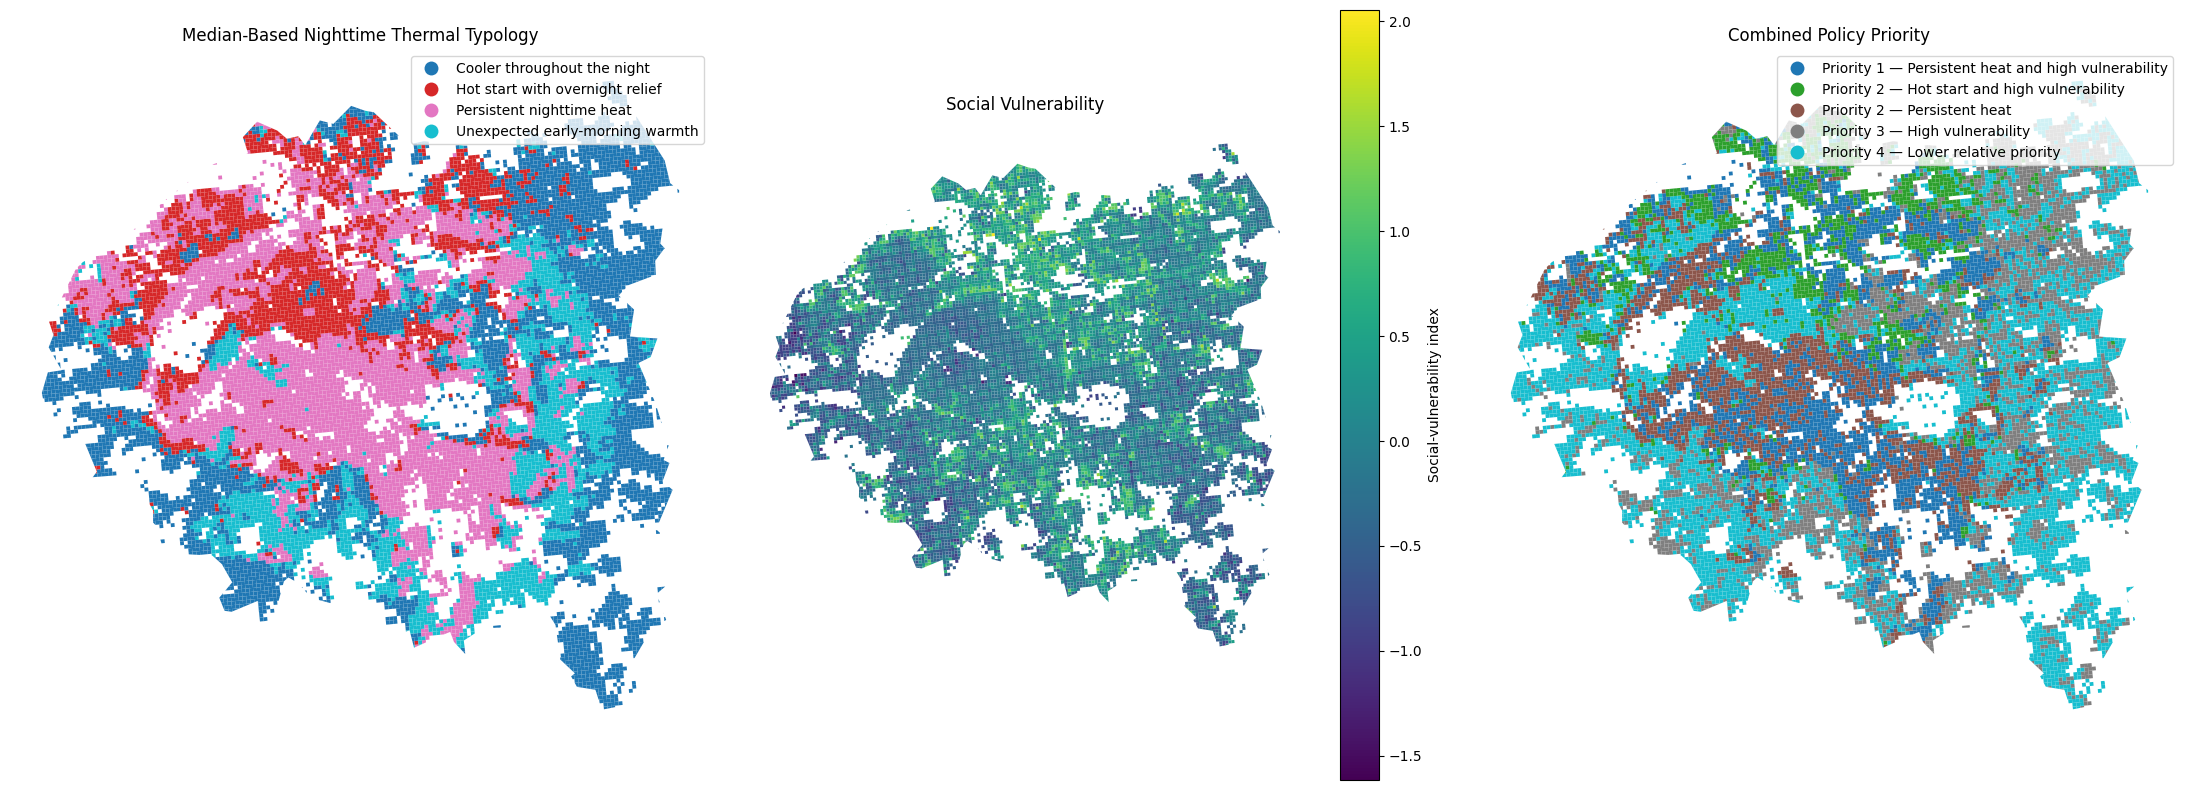

Saved: C:\Users\kbonsu\Desktop\AICC Conference\ECOSTRESS_data_processing\output\policy_priority\diagnostic_policy_priority_maps.png


In [13]:
# ============================================================
# 13. QUICK DIAGNOSTIC MAPS
# ============================================================
# These plots are for checking the classification.
# Final cartographic design can be completed in QGIS.

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

priority_gdf.plot(
    column="thermal_type_med",
    categorical=True,
    legend=True,
    ax=axes[0],
    linewidth=0,
)
axes[0].set_title("Median-Based Nighttime Thermal Typology")
axes[0].set_axis_off()

priority_gdf.plot(
    column="vulnerability_index",
    legend=True,
    ax=axes[1],
    linewidth=0,
    legend_kwds={"label": "Social-vulnerability index"},
)
axes[1].set_title("Social Vulnerability")
axes[1].set_axis_off()

priority_gdf.plot(
    column="policy_priority_med",
    categorical=True,
    legend=True,
    ax=axes[2],
    linewidth=0,
)
axes[2].set_title("Combined Policy Priority")
axes[2].set_axis_off()

plt.tight_layout()

diagnostic_map = OUTPUT_DIR / "diagnostic_policy_priority_maps.png"
plt.savefig(diagnostic_map, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", diagnostic_map)


## GeoPackage structure

The output GeoPackage contains four layers:

1. **policy_priority_200m**  
   The complete grid-level dataset, including thermal variables, vulnerability components, classifications, flags, and geometry.

2. **priority1_areas**  
   Only median-based Priority 1 cells.

3. **persistent_heat_areas**  
   All median-based persistent-nighttime-heat cells.

4. **classification_thresholds**  
   A non-spatial table recording the median and upper-quartile thresholds used in the analysis.

This structure allows QGIS users to style the full layer or work directly with selected priority subsets.


In [14]:
# ============================================================
# 14. EXPORT TO GEOPACKAGE FOR QGIS
# ============================================================

# Shorten selected long field names for broad GIS compatibility.
# The original meaning remains documented in this notebook.
export_gdf = priority_gdf.copy()

rename_for_gis = {
    "mean_cooling_magnitude": "mean_cooling",
    "single_parent_share": "single_par",
    "single_person_share": "single_per",
    "vulnerability_index": "vuln_index",
    "thermal_type_med": "therm_med",
    "thermal_detail_med": "therm_det_m",
    "thermal_type_q75": "therm_q75",
    "thermal_detail_q75": "therm_det_q",
    "policy_priority_med": "priority_m",
    "policy_priority_med_code": "priority_mc",
    "policy_priority_q75": "priority_q",
    "policy_priority_q75_code": "priority_qc",
    "adequate_temporal_coverage": "adequate_cov",
}

export_gdf = export_gdf.rename(columns=rename_for_gis)

# GeoPackage Boolean support can vary across GIS software versions.
# Convert Boolean fields to integer 0/1 for dependable QGIS filtering.
boolean_columns = export_gdf.select_dtypes(include="bool").columns

for column in boolean_columns:
    export_gdf[column] = export_gdf[column].astype("int8")

# Remove an existing output file to prevent obsolete layers from remaining.
if OUTPUT_GPKG.exists():
    OUTPUT_GPKG.unlink()

# Main complete layer
export_gdf.to_file(
    OUTPUT_GPKG,
    layer="policy_priority_200m",
    driver="GPKG",
)

# Priority 1 subset
priority1 = export_gdf[
    export_gdf["priority_m"]
    == "Priority 1 — Persistent heat and high vulnerability"
].copy()

priority1.to_file(
    OUTPUT_GPKG,
    layer="priority1_areas",
    driver="GPKG",
)

# Persistent-heat subset
persistent_heat = export_gdf[
    export_gdf["therm_med"]
    == "Persistent nighttime heat"
].copy()

persistent_heat.to_file(
    OUTPUT_GPKG,
    layer="persistent_heat_areas",
    driver="GPKG",
)

print("GeoPackage written successfully:")
print(OUTPUT_GPKG)
print("\nLayers created:")
print("- policy_priority_200m")
print("- priority1_areas")
print("- persistent_heat_areas")


GeoPackage written successfully:
C:\Users\kbonsu\Desktop\AICC Conference\ECOSTRESS_data_processing\output\policy_priority\nighttime_thermal_policy_priority_200m.gpkg

Layers created:
- policy_priority_200m
- priority1_areas
- persistent_heat_areas


In [15]:
# ============================================================
# 15. EXPORT SUPPORTING TABLES
# ============================================================

threshold_export = threshold_table.copy()
threshold_export["vulnerability_median"] = vulnerability_median
threshold_export["vulnerability_q75"] = vulnerability_q75
threshold_export["minimum_years_for_screening"] = (
    MIN_YEARS_FOR_POLICY_SCREENING
)

threshold_csv = OUTPUT_DIR / "classification_thresholds.csv"
priority_csv = OUTPUT_DIR / "policy_priority_summary.csv"
cross_table_csv = OUTPUT_DIR / "thermal_vulnerability_crosstab.csv"

threshold_export.to_csv(threshold_csv, index=False)
priority_summary.to_csv(priority_csv, index=False)
thermal_vulnerability_table.to_csv(cross_table_csv)

print("Saved supporting tables:")
print(threshold_csv)
print(priority_csv)
print(cross_table_csv)


Saved supporting tables:
C:\Users\kbonsu\Desktop\AICC Conference\ECOSTRESS_data_processing\output\policy_priority\classification_thresholds.csv
C:\Users\kbonsu\Desktop\AICC Conference\ECOSTRESS_data_processing\output\policy_priority\policy_priority_summary.csv
C:\Users\kbonsu\Desktop\AICC Conference\ECOSTRESS_data_processing\output\policy_priority\thermal_vulnerability_crosstab.csv


In [16]:
# ============================================================
# 16. FINAL VALIDATION
# ============================================================

# One geometry per grid cell
assert export_gdf["grid_id"].is_unique

# Required policy fields
required_output_fields = {
    "mean_late_night",
    "mean_early_morning",
    "mean_cooling",
    "mean_NCD",
    "vuln_index",
    "therm_med",
    "priority_m",
    "priority_mc",
    "adequate_cov",
}

missing_output_fields = required_output_fields.difference(
    export_gdf.columns
)

if missing_output_fields:
    raise ValueError(
        "Output layer is missing required fields: "
        f"{sorted(missing_output_fields)}"
    )

# Check that all grid cells received a thermal and priority class.
assert export_gdf["therm_med"].notna().all()
assert export_gdf["priority_m"].notna().all()

print("Final validation passed.")
print(f"Exported grid cells: {len(export_gdf):,}")
print(f"Priority 1 cells: {len(priority1):,}")
print(f"Persistent-heat cells: {len(persistent_heat):,}")
print("\nThe GeoPackage is ready for QGIS.")


Final validation passed.
Exported grid cells: 13,964
Priority 1 cells: 2,517
Persistent-heat cells: 4,553

The GeoPackage is ready for QGIS.


# Suggested QGIS workflow

1. Open QGIS and add `nighttime_thermal_policy_priority_200m.gpkg`.
2. Select the `policy_priority_200m` layer.
3. For the main policy map, use **Categorized symbology** on `priority_m`.
4. For the thermal typology, use **Categorized symbology** on `therm_med`.
5. Filter `adequate_cov = 1` when preparing the primary policy map.
6. Use `priority_mc` for simple ordered styling:
   - 1 = highest priority;
   - 2 = high priority;
   - 3 = vulnerability priority;
   - 4 = lower relative priority.
7. Inspect the separate `priority1_areas` layer when identifying candidate intervention zones.

## Recommended interpretation

The priority map is a screening and targeting tool. It identifies where persistent nighttime surface heat overlaps with social vulnerability. It does not by itself prescribe a specific intervention or establish causal effects.
